In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pathlib
import pandas as pd
import time
import warnings
import inspect
import pysindy.differentiation as ps_diff
warnings.filterwarnings("ignore")
import os
import glob
import re
import itertools
import pysindy as ps
from pysindy.feature_library import CustomLibrary
from pysindy.optimizers import STLSQ

# Seed the random number generators for reproducibility
np.random.seed(100)

# integration keywords for solve_ivp, typically needed for chaotic systems
integrator_keywords = {}
integrator_keywords["rtol"] = 1e-12
integrator_keywords["method"] = "LSODA"
integrator_keywords["atol"] = 1e-12

In [6]:
#Process raw data to remove any rows with -ve SOC

# Define the input subdirectory path under the current directory
INPUT_DIR = "Data"

# Find all CSV files in the 'Data' subdirectory
csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))

if not csv_files:
    print(f"No CSV files found in the '{INPUT_DIR}' subdirectory.")
else:
    print(f"Found {len(csv_files)} CSV files. Starting batch processing...")

    for file_path in csv_files:
        # Get the bare filename (e.g., "B9_data-run1.csv" or "B9-data_run1.csv")
        base_name = os.path.basename(file_path)
        # Split out the root name and extension (e.g., "B9_data-run1", ".csv")
        filename_root, file_ext = os.path.splitext(base_name)
        
        # --- UPDATED STRIPPING LOGIC ---
        # re.split(r'[-_]', ...) splits the string at the first occurrence of EITHER - or _
        # [0] grabs the very first portion before that character
        new_filename_root = re.split(r'[-_]', filename_root)[0]
        new_base_name = f"{new_filename_root}{file_ext}"
        
        # Save directly to the current directory root
        new_file_path = new_base_name
        
        print(f"Processing: {INPUT_DIR}/{base_name} --> Saved to Current Dir: {new_base_name}")
        
        try:
            # 1. Read the CSV file from 'Data/'
            df = pd.read_csv(file_path)
            
            # Verify required columns exist before performing operations
            required_cols = ["Terminal voltage [V]", "State of Charge", "Current [A]"]
            missing_cols = [col for col in required_cols if col not in df.columns]
            
            if missing_cols:
                print(f"  --> SKIPPED: Missing required source columns: {missing_cols}")
                continue

            # 2. Add new columns mapped to existing column values
            df["V"] = df["Terminal voltage [V]"]
            df["SOC"] = df["State of Charge"]
            df["I"] = df["Current [A]"]
            
            # 3. Filter rows where SOC is less than 0.0 (keep only SOC >= 0.0)
            initial_row_count = len(df)
            df = df[df["SOC"] >= 0.0]
            deleted_rows = initial_row_count - len(df)
            
            # 4. Save the modified DataFrame to the current directory root
            df.to_csv(new_file_path, index=False)
            print(f"  --> SUCCESS: Wrote new file. Cleared {deleted_rows} negative SOC rows.")
            
        except Exception as e:
            print(f"  --> ERROR processing {base_name}: {e}")

    print("\nAll files processed successfully!")

Found 5 CSV files. Starting batch processing...
Processing: Data/UDDS_results.csv --> Saved to Current Dir: UDDS.csv
  --> SUCCESS: Wrote new file. Cleared 4574 negative SOC rows.
Processing: Data/Pseudo-Random_Limit_Based_results.csv --> Saved to Current Dir: Pseudo.csv
  --> SUCCESS: Wrote new file. Cleared 0 negative SOC rows.
Processing: Data/WLTP_results.csv --> Saved to Current Dir: WLTP.csv
  --> SUCCESS: Wrote new file. Cleared 8557 negative SOC rows.
Processing: Data/HWFET_results.csv --> Saved to Current Dir: HWFET.csv
  --> SUCCESS: Wrote new file. Cleared 6231 negative SOC rows.
Processing: Data/US06_results.csv --> Saved to Current Dir: US06.csv
  --> SUCCESS: Wrote new file. Cleared 3539 negative SOC rows.

All files processed successfully!


In [3]:
# =====================================================================
# Data curation and Loading
# =====================================================================
def load_battery_data(directory="."):
    """
    Scans a directory for CSV files and extracts state and control inputs.
    Returns: dict { 'file_key': [X_array, u_array] }
    """
    csv_files = sorted(glob.glob(os.path.join(directory, "*.csv")))
    dataset_dict = {}
    for file_path in csv_files:
        file_root = os.path.splitext(os.path.basename(file_path))[0]
        try:
            df = pd.read_csv(file_path)
            if all(col in df.columns for col in ["V", "SOC", "I"]):
                X_arr = df[["V", "SOC"]].to_numpy(dtype=np.float64)
                u_arr = df[["I"]].to_numpy(dtype=np.float64)
                dataset_dict[file_root] = [X_arr, u_arr]
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    return dataset_dict

# =====================================================================
# DATA SPLITTING FUNCTION
# =====================================================================
def get_sindy_data_split(dataset_dict,set_index=0):
    """
    Use a dictionary of [X, u] array data, 
    and returns a specific training/validation split.
    
    Parameters:
    -----------
    dataset_dict : dictionary of loaded data for n datasets
    set_index : int
        An index from 0 to n-1 indicating which file to use for validation.
        
    Returns:
    --------
    X_train : list of np.ndarray
        List of state matrices for PySINDy training.
    u_train : list of np.ndarray
        List of input matrices for PySINDy training.
    X_val : np.ndarray
        State matrix for model validation.
    u_val : np.ndarray
        Input matrix for model validation.
    val_key : str
        The name of the file used for validation (useful for tracking/logging).
    """

    all_keys = list(dataset_dict.keys())
    n_files = len(all_keys)
    
    if n_files < 2:
        raise ValueError(f"Found only {n_files} valid datasets. At least 2 are required for splitting.")
        
    if set_index < 0 or set_index >= n_files:
        raise IndexError(f"set_index {set_index} is out of bounds for {n_files} datasets.")
        
    # Isolate the validation key based on the provided index
    val_key = all_keys[set_index]
    train_keys = [key for key in all_keys if key != val_key]
    
    # Extract validation arrays
    X_val, u_val = dataset_dict[val_key]
    
    # Extract and pool training arrays into lists
    X_train = []
    u_train = []
    for key in train_keys:
        X_arr, u_arr = dataset_dict[key]
        X_train.append(X_arr)
        u_train.append(u_arr)
        
    return dataset_dict, X_train, u_train, X_val, u_val, val_key

In [4]:
# =====================================================================
# CUSTOM LIBRARY FUNCTION
# =====================================================================
def getCustomLib():

    #Candidate terms

    # State Mapping: x[0]=V, x[1]=SOC, x[2]=I
    functions = [
        # --- Category 1: Constant/Bias (1 term) ---
        lambda x: 1,

        # --- Category 2: Linear Polynomials (2 terms) ---
        lambda x: x[0],      # V
        lambda x: x[1],      # SOC
        lambda x: x[2],      # I

        # --- Category 3: Pure Quadratic Polynomials (2 terms) ---
        lambda x: x[0]**2,   # V^2
        lambda x: x[1]**2,   # SOC^2
        lambda x: x[2]**2,   # I^2

        # --- Category 4: Bilinear Cross-Products; higher order polynomials (7 terms) ---
        lambda x: x[0]*x[2], # V*I
        lambda x: x[0]*x[1], # V*SOC
        lambda x: x[1]*x[2], # SOC*I
        lambda x: x[0]**3, # V^3
        lambda x: x[0]**4, # V^4
        lambda x: 1/(x[0]**2+1), # 1/(V^2 + 1)
        lambda x: x[2]**3, # I^3
        lambda x: x[2]**4, # I^4
        lambda x: 1/(x[2]**2+1), # 1/(I^2 + 1)

        # --- Category 5: Exponentials (3 terms) ---
        lambda x: np.exp(x[0]),  # exp(V)
        lambda x: np.exp(-x[0]), # exp(-V)
        lambda x: np.exp(x[1]),  # exp(SOC)
        lambda x: np.exp(x[2]),  # exp(I)

        # --- Category 6: Sinusoids (8 terms) ---
        lambda x: np.sin(x[0]), lambda x: np.cos(x[0]), # Sin(V), Cos(V)
        lambda x: np.sin(x[2]), lambda x: np.cos(x[1]), # Sin(I), Cos(I)
        lambda x: np.sin(2*x[0]), lambda x: np.cos(2*x[0]), # Sin(2V), Cos(2V)
        lambda x: np.sin(2*x[2]), lambda x: np.cos(2*x[1]), # Sin(2I), Cos(2I)

    ]

    # Provide a matching list of clean strings for PySINDy's print engine
    custom_string_names = [
        lambda x: "1",
        lambda x: "V",
        lambda x: "SOC",
        lambda x: "I",
        lambda x: "V^2",
        lambda x: "SOC^2",
        lambda x: "I^2",
        lambda x: "V*I",
        lambda x: "V*SOC",
        lambda x: "SOC*I",
        lambda x: "V^3",
        lambda x: "V^4",
        lambda x: "1/(V^2 + 1)",
        lambda x: "I^3",
        lambda x: "I^4",
        lambda x: "1/(I^2 + 1)",
        lambda x: "exp(V)",
        lambda x: "exp(-V)",
        lambda x: "exp(SOC)",
        lambda x: "exp(I)",
        lambda x: "Sin(V)",
        lambda x: "Cos(V)",
        lambda x: "Sin(I)",
        lambda x: "Cos(I)",
        lambda x: "Sin(2V)",
        lambda x: "Cos(2V)",
        lambda x: "Sin(2I)",
        lambda x: "Cos(2I)",
        # 
    ]

    # Pass the string names list to the CustomLibrary
    custom_lib = ps.CustomLibrary(
        library_functions=functions, 
        function_names=custom_string_names  # <-- This maps the strings to f3, f4, etc.
    )
    custom_lib.library_functions = functions
    return custom_lib

# =====================================================================
# SINDY MODEL USING TRAINING DATA
# =====================================================================

def TrainedModel(X,U, custom_lib, dt = 0.1 ,tol =0.0001, alpha = 0.005):

    """
    Inputs:
    X = State data (V, SOC)
    U = Control Input (I)
    custom_lib = a predefined library of custom candidate terms
    dt = time step
    tol = threshold for LSQTS
    alpha = Ridge regression regularization coeff
    

    Outputs:
    SINDyC model
    """
    # Increase threshold for actual sparsity, expose alpha for collinearity control
    optimizer = ps.STLSQ(threshold=0.00015, alpha=alpha, normalize_columns=True)

    # Build and fit the SINDyC model
    model = ps.SINDy(feature_library=custom_lib, optimizer=optimizer)
    model.fit(X, u=U, t=dt, feature_names=["V", "SOC", "I"])

    return model

    

In [12]:
# =====================================================================
# POST PROCESSING FUNCTIONS
# =====================================================================
def generate_model_trajectory_OLD(model, X_val, u_val, time_steps, dt):
    """
    Integrates an identified SINDy model forward using its initial conditions.
    Handles divergences gracefully by returning None on error.
    """
    def current_profile_interp(t):
        idx = int(round(t / dt))
        idx = min(idx, len(u_val) - 1)
        return u_val[idx]
        
    try:
        x0 = X_val[0, :]
        return model.simulate(x0, t=time_steps, u=current_profile_interp)
    except Exception:
        return None  # Flag indicating a numerical divergence occurred

def generate_model_trajectory_OLD1(model, X_val, u_val, time_steps, dt):
    """
    Integrates an identified SINDy model forward with strict physical 
    saturation guardrails to prevent numerical divergence.
    """
    def current_profile_interp(t):
        idx = int(round(t / dt))
        idx = min(idx, len(u_val) - 1)
        return u_val[idx]
        
    # Custom ODE wrapper function that clips values back to realistic battery limits
    def safe_rhs(x, t):
        # Clip the inputs going into the model to avoid exponential/polynomial explosions
        x_clipped = np.array([
            np.clip(x[0], 2.0, 4.5),  # Voltage limits
            np.clip(x[1], 0.0, 1.0)   # SOC limits
        ])
        u_t = current_profile_interp(t)
        
        # Compute the derivatives
        return model.predict(x_clipped.reshape(1, -1), u=np.array([[u_t]]))[0]

    try:
        from scipy.integrate import odeint
        x0 = X_val[0, :]
        # Swap out native model.simulate for a safe custom odeint integration block
        X_simulated = odeint(safe_rhs, x0, time_steps)
        return X_simulated
    except Exception as e:
        print(f"Integration explicitly crashed: {e}")
        return None

def generate_model_trajectory(model, X_val, u_val, time_steps, dt):
    """
    Integrates an identified SINDy model forward with strict physical 
    saturation guardrails and robust dimension checking.
    """
    if model is None:
        return None

    def current_profile_interp(t):
        # Safely map continuous time t to discrete dataset row index
        idx = int(round(t / dt))
        idx = min(idx, len(u_val) - 1)
        return u_val[idx]
        
    def safe_rhs(x, t):
        # 1. Force the input x into a clean 1D array to handle odeint's solver formatting
        x_flat = np.asarray(x).ravel()
        
        # 2. Clip states back to realistic battery limits
        v_clipped = np.clip(x_flat[0], 2.0, 4.5)
        soc_clipped = np.clip(x_flat[1], 0.0, 1.0)
        
        # 3. Reshape state to 2D array: shape (1, 2) -> [[V, SOC]]
        X_instance = np.array([[v_clipped, soc_clipped]], dtype=np.float64)
        
        # 4. Fetch the interpolated current control scalar and shape to 2D: shape (1, 1) -> [[I]]
        u_t = current_profile_interp(t)
        u_instance = np.atleast_2d(u_t).to_numpy() if hasattr(u_t, 'to_numpy') else np.array([[u_t]], dtype=np.float64)
        
        # 5. Predict the derivative vector: outputs [[dV/dt, dSOC/dt]]
        x_dot = model.predict(X_instance, u=u_instance)
        
        # 6. Flatten back to a 1D array array of shape (2,) required by odeint output specifications
        return x_dot.ravel()

    try:
        from scipy.integrate import odeint
        x0 = X_val[0, :] # Extract starting conditions [V0, SOC0]
        X_simulated = odeint(safe_rhs, x0, time_steps)
        return X_simulated
    except Exception as e:
        print(f"Integration explicitly crashed: {e}")
        return None

# =====================================================================
# VISUALIZATION & ANALYSIS 
# =====================================================================
def plot_matrix_performance(metrics_df):
    """Plots comparative metrics (AIC, RMSE, NRMSE_V, NRMSE_SOC, Coefficient Counts) for optimal runs."""
    # Group to extract the optimal (minimum AIC) configuration row for each unique dataset run
    opt_indices = metrics_df.groupby("Validation_Key")["AIC"].idxmin()
    best_metrics = metrics_df.loc[opt_indices].sort_values(by="Validation_Key")
    
    keys = best_metrics["Validation_Key"].tolist()
    aics = best_metrics["AIC"].tolist()
    rmses = best_metrics["RMSE"].tolist()
    nrmse_v = best_metrics["NRMSE_V"].tolist()      
    nrmse_soc = best_metrics["NRMSE_SOC"].tolist()
    coeffs = best_metrics["Num_Coeffs"].tolist()
    
    x = np.arange(len(keys))
    width = 0.35  # Width of the grouped bars
    
    #fig, axes = plt.subplots(4, 1, figsize=(10, 15), sharex=True)
    fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
    # Subplot 1: Akaike Information Criterion
    axes[0].bar(x, aics, color="#d62728", edgecolor="black", alpha=0.8, width=0.4)
    axes[0].set_ylabel("Optimal AIC Score (Symlog)", fontsize=10, fontweight="bold")
    axes[0].set_yscale('symlog', linthresh=1.0) 
    axes[0].axhline(y=0.0, color="black", linestyle="-", linewidth=0.8) # Baseline anchor
    axes[0].grid(True, which="both", linestyle=":", alpha=0.6)
    axes[0].set_title("Optimal SINDyC Cross-Validation Performance Metrics Matrix", fontsize=12, fontweight="bold")
    
    # Subplot 2: Root Mean Squared Error (Global RMSE)
    axes[1].bar(x, rmses, color="#1f77b4", edgecolor="black", alpha=0.8, width=0.4)
    axes[1].set_ylabel("Validation Global RMSE", fontsize=10, fontweight="bold")
    axes[1].set_yscale("log")
    axes[1].grid(True, which="both", linestyle=":", alpha=0.6)

    # Subplot 3: Root Mean Squared Error (RMSE_V, RMSE_SOC)
    rects1 = axes[2].bar(x - width/2, nrmse_v, width, label="Voltage ($\dot{V}$) NRMSE", 
                        color="#1f77b4", edgecolor="black", alpha=0.85)
    rects2 = axes[2].bar(x + width/2, nrmse_soc, width, label="SOC ($\dot{\mathrm{SOC}}$) NRMSE", 
                        color="#2ca02c", edgecolor="black", alpha=0.85)
    
    axes[2].set_ylabel("Validation NRMSE [% of Range]", fontsize=10, fontweight="bold")
    axes[2].set_yscale("log")
    axes[2].grid(True, linestyle=":", alpha=0.6)
    axes[2].legend(loc="upper right", frameon=True, shadow=True)
    
    # Add a subtle horizontal line at 5% as an engineering acceptance threshold
    axes[2].axhline(y=5.0, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="5% Error Threshold")
    
    # Subplot 4: Discovered Complexity Profile
    #axes[3].bar(x, coeffs, color="#2ca02c", edgecolor="black", alpha=0.8, width=0.4)
    #axes[3].set_ylabel("No. of Discovered Coeffs", fontsize=10, fontweight="bold")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(keys, rotation=25, ha="right")
    axes[2].set_xlabel("Left-Out Validation Dataset Key", fontsize=11, fontweight="bold", labelpad=10)
    #axes[3].grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# =====================================================================
# Plot trajectories
# =====================================================================

def plot_trajectory_comparison(simulations_registry):
    """Plots simulated versus measured timelines for V and SOC across all files."""
    keys = list(simulations_registry.keys())
    n_plots = len(keys)
    
    fig, axes = plt.subplots(n_plots, 2, figsize=(14, 3 * n_plots), squeeze=False)
    
    for idx, key in enumerate(keys):
        sim_data = simulations_registry[key]
        t = sim_data["time"]
        X_true = sim_data["true_trajectory"]
        X_sim = sim_data["sim_trajectory"]
        
        # --- Voltage Panel ---
        axes[idx, 0].plot(t, X_true[:, 0], "k-", label="Measured Data", linewidth=1.5)
        if X_sim is not None:
            # FIX: Changed "r--" (removed any potential hidden artifacts)
            axes[idx, 0].plot(t, X_sim[:, 0], "r--", label="AIC Optimal SINDy", linewidth=1.5)
        else:
            axes[idx, 0].text(0.5, 0.5, "Failed to integrate trajectories", color="red", ha="center", transform=axes[idx, 0].transAxes)
        axes[idx, 0].set_ylabel(f"{key}\nVoltage [V]", fontsize=10, fontweight="bold")
        axes[idx, 0].grid(True, linestyle=":", alpha=0.5)
        
        # --- SOC Panel ---
        axes[idx, 1].plot(t, X_true[:, 1], "k-", label="Measured Data", linewidth=1.5)
        if X_sim is not None:
            axes[idx, 1].plot(t, X_sim[:, 1], "b--", label="AIC Optimal SINDy", linewidth=1.5)
        else:
            axes[idx, 1].text(0.5, 0.5, "Failed to integrate trajectories", color="red", ha="center", transform=axes[idx, 1].transAxes)
        axes[idx, 1].set_ylabel("SOC [0-1]", fontsize=10, fontweight="bold")
        axes[idx, 1].grid(True, linestyle=":", alpha=0.5)
        
        if idx == 0:
            axes[0, 0].set_title("Terminal Voltage ($V$) Trajectories", fontsize=12, fontweight="bold")
            axes[0, 1].set_title("State of Charge ($\mathrm{SOC}$) Trajectories", fontsize=12, fontweight="bold")
            axes[0, 0].legend(loc="upper right")

    for ax_row in axes:
        ax_row[0].set_xlabel("Time [Seconds]")
        ax_row[1].set_xlabel("Time [Seconds]")
        
    plt.tight_layout()
    plt.show()

# =====================================================================
# Print best model 
# =====================================================================


def print_optimal_sindy_equations(analysis_registry):
    """
    Identifies the minimum AIC hyperparameter set for each validation fold split
    and prints the corresponding discovered governing differential equations.
    
    Parameters:
    -----------
    analysis_registry : dict
        The output registry dictionary containing 'metrics_df' and 'best_models'.
    """
    metrics_df = analysis_registry["metrics_df"]
    best_models_dict = analysis_registry["best_models"]
    
    # Locate the row index of the minimum AIC score for each unique validation dataset
    optimal_indices = metrics_df.groupby("Validation_Key")["AIC"].idxmin()
    best_runs_df = metrics_df.loc[optimal_indices]
    
    print("=" * 80)
    print("                 DISCOVERED SINDyC GOVERNING EQUATIONS PROFILE          ")
    print("=" * 80)
    
    for _, row in best_runs_df.iterrows():
        val_key = row["Validation_Key"]
        opt_tol = row["Threshold_tol"]
        opt_alpha = row["Ridge_alpha"]
        score_aic = row["AIC"]
        active_terms = row["Num_Coeffs"]
        
        print(f"\n▶ VALIDATION SPLIT HELD OUT: '{val_key}'")
        print(f"  [Hyperparameters Chosen via Min AIC]: tol (Sparsity) = {opt_tol} | alpha (Ridge) = {opt_alpha}")
        print(f"  [Model Metrics Metrics]: Minimum AIC = {score_aic:.2f} | Active Library Terms = {active_terms}")
        print(f"  " + "-" * 70)
        
        # Retrieve the matching fitted SINDy model object from the sub-dictionary
        optimal_model = best_models_dict.get(val_key)
        
        if optimal_model is not None:
            # Displays equations formatted directly as dV/dt = ... and dSOC/dt = ...
            optimal_model.print()
        else:
            print("  Warning: No valid fitted model object found for this data key.")
            
        print("  " + "-" * 70)
        
    print("\n" + "=" * 80)

def plot_coefficient_matrix_from_dict(analysis_registry):
    """
    Extracts coefficient values directly from the isolated dictionary registry
    and plots a comparative heatmap grid across all validation splits.
    """
    coef_registry = analysis_registry["coefficients"]
    
    # Reshape the nested dictionary structure into clear standalone states
    v_matrix_data = {}
    soc_matrix_data = {}
    
    for split_key, equations in coef_registry.items():
        v_matrix_data[split_key] = equations.get("dV_dt", {})
        soc_matrix_data[split_key] = equations.get("dSOC_dt", {})
        
    # Convert to DataFrames (Rows = Candidate Features, Columns = Validation Splits)
    # Fill NaN values with 0.0 to indicate the term was pruned by the optimizer
    df_v_coefs = pd.DataFrame.from_dict(v_matrix_data).fillna(0.0)
    df_soc_coefs = pd.DataFrame.from_dict(soc_matrix_data).fillna(0.0)
    
    # Create the visual heatmap canvas layout
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # --- Panel 1: Voltage Derivative Coefficients ---
    im1 = axes[0].imshow(df_v_coefs.to_numpy(), cmap="RdBu", aspect="auto", 
                         vmin=-max(1, df_v_coefs.abs().max().max()), 
                         vmax=max(1, df_v_coefs.abs().max().max()))
    axes[0].set_yticks(np.arange(len(df_v_coefs.index)))
    axes[0].set_yticklabels(df_v_coefs.index, fontsize=10, fontweight="bold")
    axes[0].set_xticks(np.arange(len(df_v_coefs.columns)))
    axes[0].set_xticklabels(df_v_coefs.columns, rotation=30, ha="right", fontsize=10)
    axes[0].set_title("Discovered Coefficients for $\dot{V}$ Equation", fontsize=12, fontweight="bold")
    fig.colorbar(im1, ax=axes[0], label="Coefficient Numerical Value")
    
    # Annotate values inside the matrix grid squares
    for i in range(len(df_v_coefs.index)):
        for j in range(len(df_v_coefs.columns)):
            val = df_v_coefs.to_numpy()[i, j]
            if abs(val) > 1e-3:#1 e-4
                axes[0].text(j, i, f"{val:.3f}", ha="center", va="center", 
                             color="white" if abs(val) > 0.5 * df_v_coefs.abs().max().max() else "black")

    # --- Panel 2: SOC Derivative Coefficients ---
    im2 = axes[1].imshow(df_soc_coefs.to_numpy(), cmap="RdBu", aspect="auto",
                         vmin=-max(0.1, df_soc_coefs.abs().max().max()), 
                         vmax=max(0.1, df_soc_coefs.abs().max().max()))
    axes[1].set_yticks(np.arange(len(df_soc_coefs.index)))
    axes[1].set_yticklabels(df_soc_coefs.index, fontsize=10, fontweight="bold")
    axes[1].set_xticks(np.arange(len(df_soc_coefs.columns)))
    axes[1].set_xticklabels(df_soc_coefs.columns, rotation=30, ha="right", fontsize=10)
    axes[1].set_title("Discovered Coefficients for $\dot{\mathrm{SOC}}$ Equation", fontsize=12, fontweight="bold")
    fig.colorbar(im2, ax=axes[1], label="Coefficient Numerical Value")
    
    # Annotate values inside the matrix grid squares
    for i in range(len(df_soc_coefs.index)):
        for j in range(len(df_soc_coefs.columns)):
            val = df_soc_coefs.to_numpy()[i, j]
            if abs(val) > 1e-3:#1 e-5
                axes[1].text(j, i, f"{val:.4f}", ha="center", va="center",
                             color="white" if abs(val) > 0.5 * df_soc_coefs.abs().max().max() else "black")

    plt.tight_layout()
    plt.show()

def print_dictionary_coefficients(analysis_registry):
    """Prints coefficients directly from the isolated dictionary storage."""
    coef_registry = analysis_registry["coefficients"]
    
    print("\n" + "="*80)
    print("               ISOLATED GOVERNING MATHEMATICAL EQUATIONS COEF DICT")
    print("="*80)
    
    for split_key, equations in coef_registry.items():
        print(f"\n▶ VALIDATION SPLIT TRACK HELD OUT: '{split_key}'")
        print("-" * 60)
        
        # Print Voltage Terms
        v_dict = equations.get("dV_dt", {})
        v_string = " + ".join([f"({val:+.4f})*{name}" for name, val in v_dict.items()])
        print(f"  dV/dt = {v_string if v_string else '0.0'}\n")
        
        # Print SOC Terms
        soc_dict = equations.get("dSOC_dt", {})
        soc_string = " + ".join([f"({val:+.4f})*{name}" for name, val in soc_dict.items()])
        print(f"  dSOC/dt = {soc_string if soc_string else '0.0'}")
        print("="*80)

In [13]:
# =====================================================================
# HYPERPARAMETER SCANNING USING SINDY MODEL
# =====================================================================
def run_hyperparameter_scan(dataset_dict, threshold_grid, alpha_grid, dt=0.1):
    """
    Executes an N-fold cross-validation grid search to find optimal hyperparameters.
    
    Returns:
    --------
    analysis_registry : dict
        Nested dictionary layout tracking everything needed for modeling & plotting:
        {
          'metrics_df': pd.DataFrame,
          'simulations': { 'val_key': { 't': array, 'true': array, 'sim': array/None } },
          'best_models': { 'val_key': ps.SINDy }
        }
    """
    all_keys = list(dataset_dict.keys())
    #custom_lib = getCustomLib()
    diff_method = ps.FiniteDifference(order=2)
    
    results_records = []
    simulations_registry = {}
    best_models_registry = {}
    # Dictionary to store only the best coefficient profiles per split
    best_coefficients_registry = {}
    
    print(f"Executing search grid matrix across {len(all_keys)} splits...")

    for val_key in all_keys:
        train_keys = [k for k in all_keys if k != val_key]
        X_train = [dataset_dict[k][0] for k in train_keys]
        u_train = [dataset_dict[k][1] for k in train_keys]
        X_val, u_val = dataset_dict[val_key]
        
        x_dot_val_true = diff_method(X_val, t=dt)
        n_samples = X_val.shape[0]
        time_steps = np.arange(n_samples) * dt
        
        best_aic = float('inf')
        best_model = None
        
        # Grid loop
        for tol, alpha in itertools.product(threshold_grid, alpha_grid):
            #
            custom_lib = getCustomLib()
            optimizer = ps.STLSQ(threshold=0.00015, alpha=alpha, normalize_columns=True,  max_iter=20)
            # Build and fit the SINDyC model
            model = ps.SINDy(feature_library=custom_lib, optimizer=optimizer)
            model.fit(X_train, u=u_train, t=dt, feature_names=["V", "SOC", "I"])
            
            x_dot_val_pred = model.predict(X_val, u=u_val)
            
            ##calculate normalized rmse and aic

            # Compute individual errors per state variable
            mse_per_state = np.mean((x_dot_val_true - x_dot_val_pred) ** 2, axis=0)  # [MSE_V, MSE_SOC]

            global_rmse = np.sqrt(np.mean(mse_per_state))
            
            # Calculate the peak-to-peak range of the true derivatives to use as scale factors
            range_V_dot = np.ptp(x_dot_val_true[:, 0])
            range_SOC_dot = np.ptp(x_dot_val_true[:, 1])
            
            # Compute Normalized RMSE (expressed as a percentage of the total operating range)
            nrmse_V = (np.sqrt(mse_per_state[0]) / range_V_dot) * 100
            nrmse_SOC = (np.sqrt(mse_per_state[1]) / range_SOC_dot) * 100

            # Compute a Normalized Global MSE to feed into a balanced AIC calculation
            # This prevents Voltage from dominating the information criterion metric
            mse = ( (np.sqrt(mse_per_state[0]) / range_V_dot)**2 + 
                 (np.sqrt(mse_per_state[1]) / range_SOC_dot)**2 ) / 2

            #mse = np.mean((x_dot_val_true - x_dot_val_pred) ** 2)
            active_coeffs = np.count_nonzero(model.coefficients())
            print("active_coeffs",tol,alpha, active_coeffs)

            aic = 2 * active_coeffs + n_samples * np.log(mse) if mse > 0 else float('-inf')
            
            results_records.append({
                "Validation_Key": val_key, "Threshold_tol": tol, "Ridge_alpha": alpha,"RMSE": global_rmse, 
                "NRMSE_V": nrmse_V, "NRMSE_SOC": nrmse_SOC,
                "RMSE": np.sqrt(mse), "AIC": aic, "Num_Coeffs": active_coeffs
            })
            # If this is the best model structure so far, extract its coefficients into a dictionary
            if aic < best_aic and active_coeffs > 0:
                best_aic = aic
                best_model = model
                
                # Extract terms and map them directly to feature name strings
                names = model.get_feature_names()
                raw_coefs = model.coefficients()
                
                # Build an explicit mathematical map for this validation split execution
                best_features_mapped = {
                    "dV_dt": {names[i]: raw_coefs[0, i] for i in range(len(names)) if abs(raw_coefs[0, i]) > 1e-5},
                    "dSOC_dt": {names[i]: raw_coefs[1, i] for i in range(len(names)) if abs(raw_coefs[1, i]) > 1e-5}
                }           

        # Cache top-performing model for this fold split
        best_models_registry[val_key] = best_model

        best_coefficients_registry[val_key] = best_features_mapped # Save map to registry
        
        # Generate the continuous dynamic trajectory for this specific top performer
        print(f"  > Simulating optimal model trajectory for validation target: {val_key}")
        sim_trajectory = generate_model_trajectory(best_model, X_val, u_val, time_steps, dt)
        
        simulations_registry[val_key] = {
            "time": time_steps,
            "true_trajectory": X_val,
            "sim_trajectory": sim_trajectory
        }
        
    return {
        "metrics_df": pd.DataFrame(results_records),
        "simulations": simulations_registry,
        "best_models": best_models_registry,
        "coefficients": best_coefficients_registry
    }    

Executing search grid matrix across 5 splits...
active_coeffs 1e-05 0.001 166
active_coeffs 1e-05 0.005 167
active_coeffs 1e-05 0.01 165
active_coeffs 1e-05 0.1 158
active_coeffs 1e-05 0.25 154
active_coeffs 5e-05 0.001 166
active_coeffs 5e-05 0.005 167
active_coeffs 5e-05 0.01 165
active_coeffs 5e-05 0.1 158
active_coeffs 5e-05 0.25 154
active_coeffs 0.0001 0.001 166
active_coeffs 0.0001 0.005 167
active_coeffs 0.0001 0.01 165
active_coeffs 0.0001 0.1 158
active_coeffs 0.0001 0.25 154
active_coeffs 0.001 0.001 166
active_coeffs 0.001 0.005 167
active_coeffs 0.001 0.01 165
active_coeffs 0.001 0.1 158
active_coeffs 0.001 0.25 154
active_coeffs 0.1 0.001 166
active_coeffs 0.1 0.005 167
active_coeffs 0.1 0.01 165
active_coeffs 0.1 0.1 158
active_coeffs 0.1 0.25 154
  > Simulating optimal model trajectory for validation target: HWFET
Integration explicitly crashed: index 1 is out of bounds for axis 0 with size 1
active_coeffs 1e-05 0.001 168
active_coeffs 1e-05 0.005 167
active_coeffs 1e-0

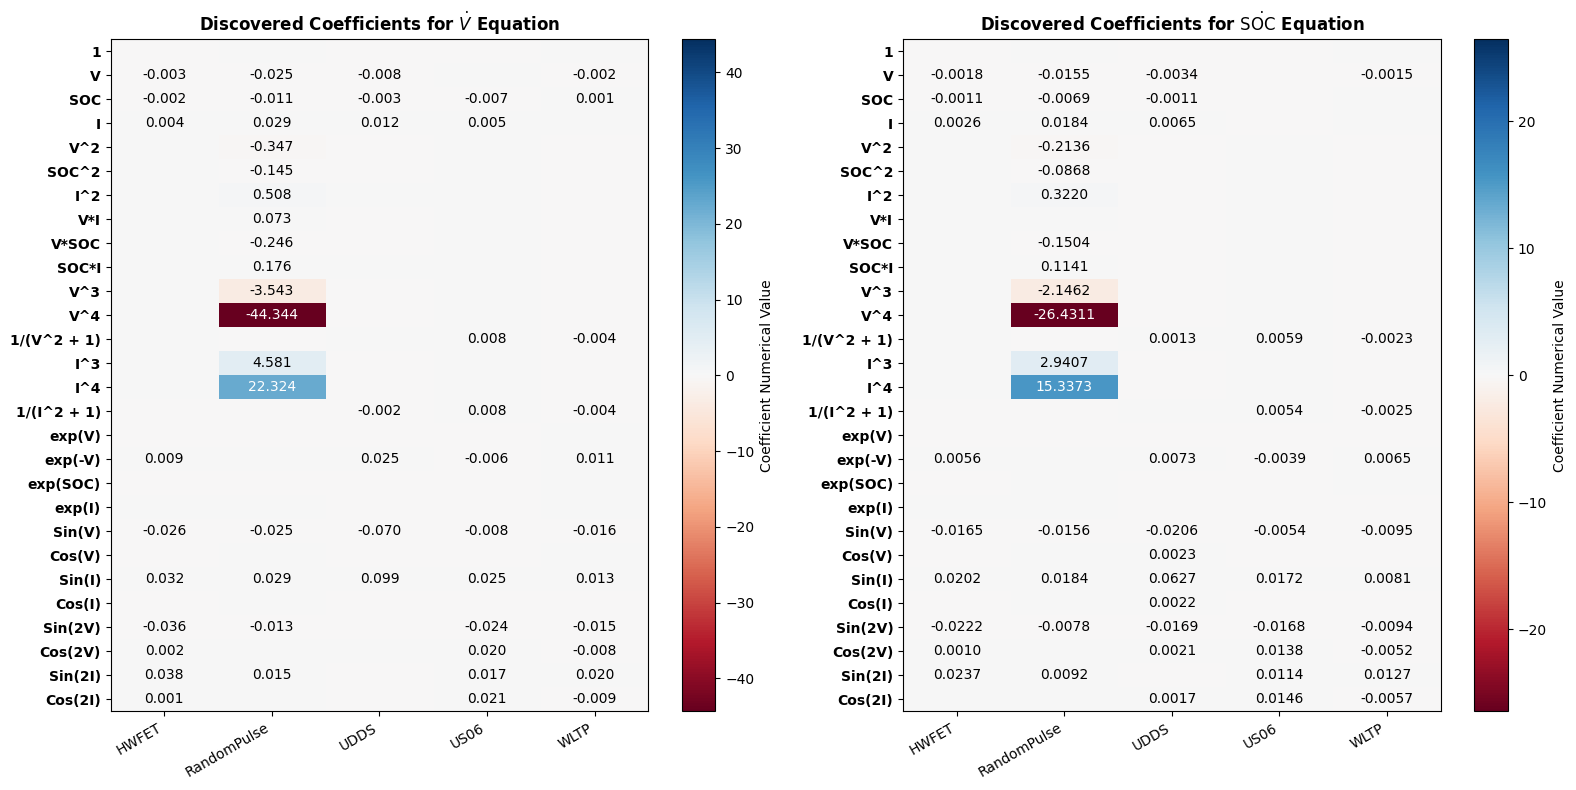

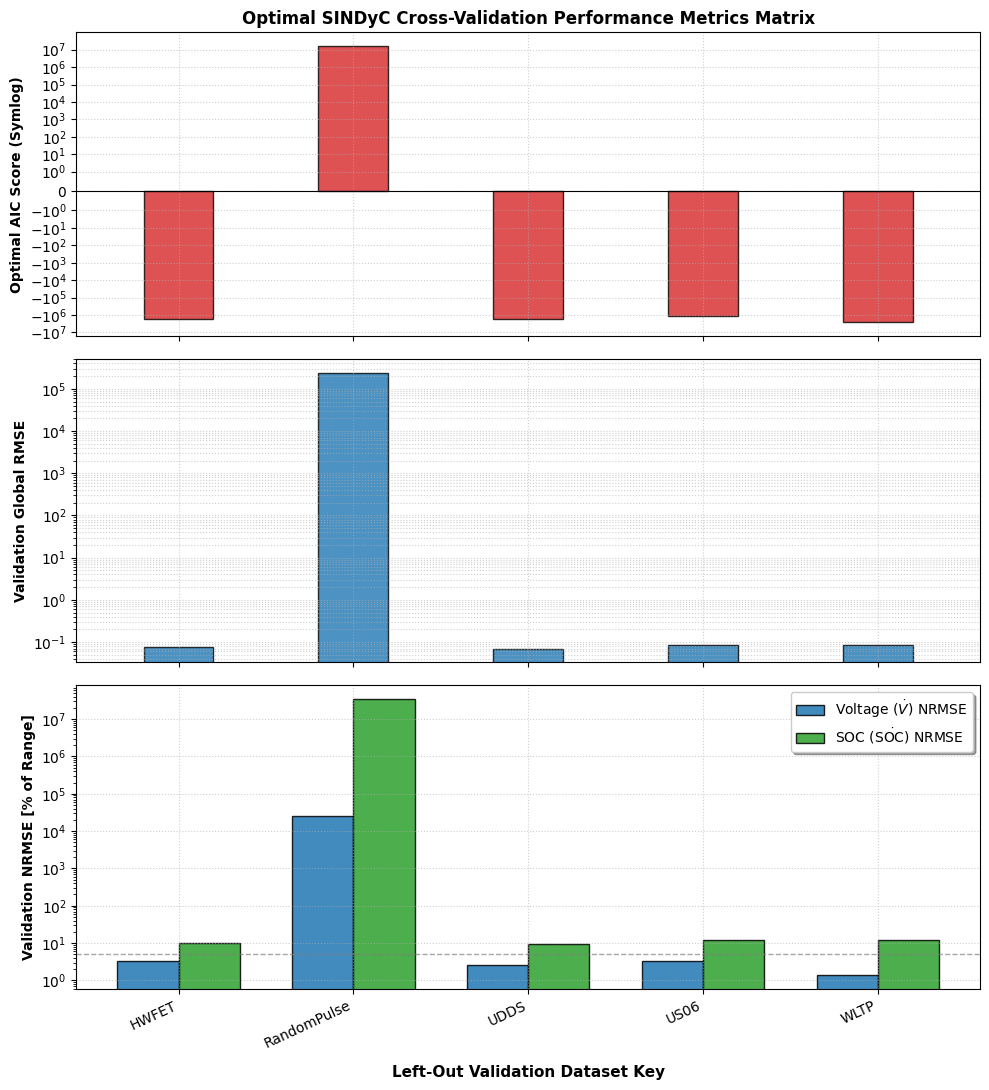

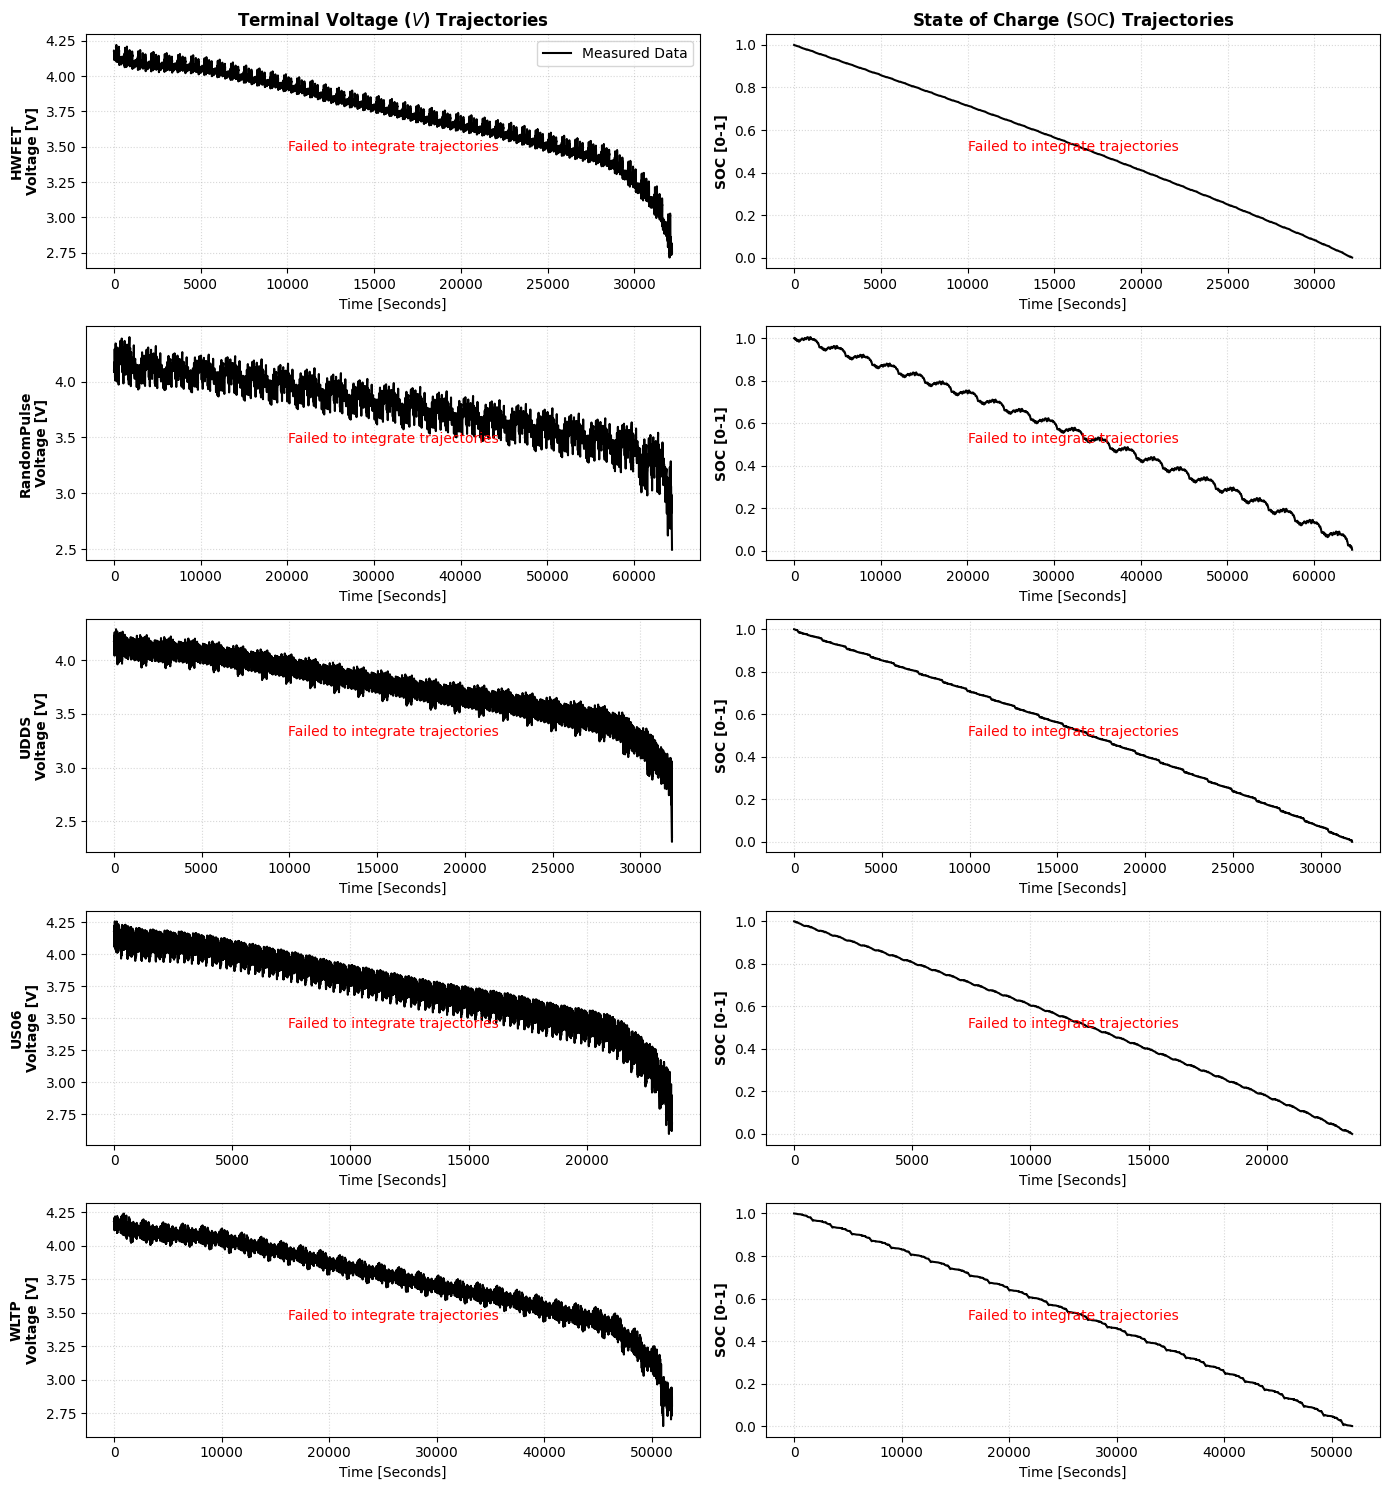

In [15]:
# =====================================================================
# 4. EXECUTION PIPELINE ENTRY POINT
# =====================================================================
if __name__ == "__main__":
    # Load data from workspace
    raw_data = load_battery_data()
    
    if not raw_data:
        print("Pipeline terminated: No valid CSV files containing V, SOC, and I targets discovered.")
    else:
        # Configuration setup parameters
        TOL_SCAN = [0.00001, 0.00005, 0.0001, 0.001,0.1]
        ALPHA_SCAN = [0.001, 0.005, 0.01, 0.1, 0.25]
        #
        SAMPLING_INTERVAL = 0.1
        
        # Run functional optimizer engine
        analysis_registry = run_hyperparameter_scan(
            dataset_dict=raw_data,
            threshold_grid=TOL_SCAN,
            alpha_grid=ALPHA_SCAN,
            dt=SAMPLING_INTERVAL
        )
        # Print the best-fitted physical models to the terminal console
        print_optimal_sindy_equations(analysis_registry)

        # Plot the comparative dictionary coefficient matrix visually 
        plot_coefficient_matrix_from_dict(analysis_registry)
        
        # Deploy independent plotting blocks
        plot_matrix_performance(analysis_registry["metrics_df"])
        plot_trajectory_comparison(analysis_registry["simulations"])